<a href="https://colab.research.google.com/github/wantuds-crypto/Ciencia-datos-curso/blob/main/Final_precios_inmuebles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Introducción y objetivo del análisis
### El problema
**Problemática:** predecir o explicar el precio de venta de una vivienda a partir de sus características físicas y de ubicación, para apoyar decisiones como fijar el precio de listado, detectar propiedades sub o sobrevaloradas y entender qué atributos elevan más el valor de una casa.

El precio de una vivienda depende de muchas cosas a la vez: su tamaño, su estado, su antigüedad, si tiene vista o frente al agua y, sobre todo, **dónde está**. Para quien compra, vende, construye o financia vivienda, entender **qué características se asocian con un precio más alto** permite tomar mejores decisiones: fijar precios de lista, priorizar zonas de inversión, decidir si conviene renovar o detectar ventas con precios anómalos.

### Objetivo general
Identificar, con los datos disponibles, qué características de la vivienda y de su ubicación se relacionan más con su **precio de venta**, y dejar el terreno preparado (datos limpios, variables construidas y evaluadas) para un futuro modelo de estimación de precios.

### Preguntas que queremos responder
1. ¿Qué tan confiables son los datos y qué problemas de calidad tienen?
2. ¿Cómo se distribuye el precio de venta? ¿Hay valores imposibles o sospechosos?
3. ¿Qué zonas y ciudades concentran las ventas y cuáles tienen precios más altos?
4. ¿Cómo cambia el precio según el tamaño, la antigüedad, el estado y la calidad de la vista?
5. ¿Qué variables (originales o construidas) tienen la relación más fuerte con el precio?
6. ¿Qué recomendaciones prácticas y qué próximos pasos se derivan?

In [83]:
# --- Librerías ---
from pathlib import Path
import re
import warnings
import os
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import duckdb
from scipy import stats
import kagglehub

In [84]:
# Descarga del dataset
path = kagglehub.dataset_download("debayank2024/house-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-price-prediction' dataset.
Path to dataset files: /kaggle/input/house-price-prediction


## 1. Primer vistazo a los datos
Antes de limpiar o transformar nada, simplemente abrimos el archivo para ver que contiene: cuantas ventas hay, que columnas trae y como se ven los primeros registros. Este paso no cambia ni corrige nada, solo nos deja ver el punto de partida. El archivo trae 4.600 ventas de viviendas; cada fila es una casa vendida, con datos como precio, numero de habitaciones, tamano, ano de construccion y ubicacion. A partir de aqui decidiremos que hay que corregir.

In [85]:
df = pd.read_csv(os.path.join(path, "modified_data.csv"))
raw = df.copy()  # copia original sin modificar (se usa en el diagnostico y en limpiar)
print("Filas y columnas:", df.shape)
df.info()
df.head()

Filas y columnas: (4600, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  pric

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [86]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


#Diagnóstico rápido de calidad (EDA inicial)
 Esta tabla responde una sola pregunta: ¿qué problemas tiene el archivo y cuántos registros afecta cada uno? Así cada decisión de la limpieza queda justificada con un número.

In [87]:
anio_venta = pd.to_datetime(raw["date"]).dt.year.max()
diagnostico = pd.DataFrame({
    "Revisión": ["Filas duplicadas exactas", "Celdas vacías (nulos)", "Precio igual a 0",
                 "0 habitaciones y 0 baños", "Año de renovación = 0 (nunca renovada)",
                 "Renovación anterior a la construcción", "Rango de fechas de venta"],
    "Resultado": [raw.duplicated().sum(), int(raw.isna().sum().sum()), (raw["price"] == 0).sum(),
                  ((raw["bedrooms"] == 0) & (raw["bathrooms"] == 0)).sum(), (raw["yr_renovated"] == 0).sum(),
                  ((raw["yr_renovated"] > 0) & (raw["yr_renovated"] < raw["yr_built"])).sum(),
                  f"{raw['date'].min()} a {raw['date'].max()}"],
})
diagnostico

,Revisión,Resultado
0,Filas duplicadas exactas,0
1,Celdas vacías (nulos),0
2,Precio igual a 0,49
3,0 habitaciones y 0 baños,2
4,Año de renovación = 0 (nunca renovada),2735
5,Renovación anterior a la construcción,195
6,Rango de fechas de venta,2014-05-02 a 2014-07-10


**Qué encontramos.** El archivo parece limpio: 0 duplicados, 0 celdas vacías.

- Esconde *nulos disfrazados de cero*: 49 precios en US 0.
- 2 casas sin habitaciones ni baños
- 2.735 años de renovación en 0 (que significan “nunca renovada”).
- 195 renovaciones con fecha anterior a la construcción.

- las ventas cubren solo 70 días (mayo–julio 2014), lo que limita cualquier análisis de tendencia.

## 2. Limpieza de los datos

 Encontramos varios problemas "escondidos": ceros que no son ceros reales sino la forma en que el sistema marca "no aplica" o "no se registro", y algunos precios que son errores evidentes de digitacion. La regla que seguimos en todo el proceso es la misma: nunca eliminamos una fila completa; en cambio, marcamos el problema y excluimos esos registros solo de los calculos donde afectarian el resultado. Asi, cualquier persona puede revisar despues que se marco y por que, y decidir si esta de acuerdo. A continuacion se resumen los cuatro grupos de problemas que se corrigieron.

In [89]:
df.select_dtypes(include=['bool']).info()
df.select_dtypes(include=['object']).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Empty DataFrame
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   street    4600 non-null   object
 1   city      4600 non-null   object
 2   statezip  4600 non-null   object
dtypes: object(3)
memory usage: 107.9+ KB


In [90]:
MAPA_COLUMNAS = {
    "date": "fecha", "price": "precio", "bedrooms": "habitaciones", "bathrooms": "banos",
    "sqft_living": "area_construida_sqft", "sqft_lot": "area_lote_sqft", "floors": "pisos",
    "waterfront": "frente_agua", "view": "vista", "condition": "condicion",
    "sqft_above": "area_sobre_suelo_sqft", "sqft_basement": "area_sotano_sqft",
    "yr_built": "anio_construccion", "yr_renovated": "anio_renovacion", "street": "direccion",
    "city": "ciudad", "statezip": "estado_zip", "price_per_sqft": "precio_por_sqft",
}

def limpiar(raw: pd.DataFrame):
    df = raw.copy()
    bitacora = []

    # 1) Nombres, texto e identificador unico
    df = df.rename(columns=MAPA_COLUMNAS)
    df.columns = [re.sub(r"[^a-z0-9_]", "_", c.strip().lower()) for c in df.columns]
    for c in ["direccion", "ciudad", "estado_zip"]:
        df[c] = df[c].astype("string").str.strip().str.replace(r"\s{2,}", " ", regex=True)
    df["ciudad"] = df["ciudad"].str.title().str.replace("Seatac", "SeaTac")
    partes = df["estado_zip"].str.extract(r"^(?P<estado>[A-Z]{2})\s(?P<codigo_postal>\d{5})$")
    df = pd.concat([df.drop(columns="estado_zip"), partes], axis=1)
    df.insert(0, "id_inmueble", [f"INM-{i:05d}" for i in range(1, len(df) + 1)])
    bitacora.append(["1. Nombres, texto e identificador",
                      "Columnas en ingles sin id unico; texto con espacios/mayusculas inconsistentes",
                      "Traducir nombres, limpiar texto, separar estado/codigo postal, crear id_inmueble",
                      len(df)])

    # 2) Precio en cero y precios imposibles
    df["flag_precio_no_registrado"] = df["precio"] == 0
    df.loc[df["flag_precio_no_registrado"], "precio"] = np.nan
    df["precio_por_sqft"] = (df["precio"] / df["area_construida_sqft"]).round(2)
    log_pps = np.log(df["precio_por_sqft"].where(df["precio_por_sqft"] > 0))
    q1, q3 = log_pps.quantile([.25, .75]); iqr = q3 - q1
    df["flag_precio_extremo"] = ((log_pps < q1 - 3 * iqr) | (log_pps > q3 + 3 * iqr)).fillna(False)
    bitacora.append(["2. Precios en cero y precios imposibles",
                      f"{int(df['flag_precio_no_registrado'].sum())} ventas en US$0 y precios por pie2 absurdos",
                      "Marcar como nulo/atipico y excluir del analisis del precio (sin borrar filas)",
                      int(df["flag_precio_no_registrado"].sum() + df["flag_precio_extremo"].sum())])

    # 3) Habitaciones/banos en cero y renovacion inconsistente
    m0 = (df["habitaciones"] == 0) & (df["banos"] == 0)
    df.loc[m0, ["habitaciones", "banos"]] = np.nan
    m_nunca = df["anio_renovacion"] == 0
    m_inc = (df["anio_renovacion"] > 0) & (df["anio_renovacion"] < df["anio_construccion"])
    df["flag_renovacion_inconsistente"] = m_inc
    df.loc[m_nunca | m_inc, "anio_renovacion"] = np.nan
    bitacora.append(["3. Habitaciones/banos en 0 y renovacion inconsistente",
                      f"{int(m0.sum())} casas grandes con 0 habitaciones/banos; anos de renovacion en 0 o anteriores a la construccion",
                      "Convertir a nulo (dato desconocido / no aplica) y marcar inconsistencias",
                      int(m0.sum() + (m_nunca | m_inc).sum())])

    # 4) Direcciones repetidas y lotes atipicos
    df["flag_direccion_repetida"] = df.duplicated(["direccion", "ciudad", "codigo_postal"], keep=False)
    bitacora.append(["4. Direcciones repetidas y lotes muy grandes",
                      "Direcciones repetidas (casas distintas) y lotes rurales muy grandes",
                      "No se elimina nada: se marcan direcciones repetidas y se recomienda usar medianas para los lotes",
                      int(df["flag_direccion_repetida"].sum())])

    return df, pd.DataFrame(bitacora, columns=["Paso", "Problema encontrado", "Que se hizo", "Registros afectados"])

df, bitacora = limpiar(raw)
bitacora

,Paso,Problema encontrado,Que se hizo,Registros afectados
0,"1. Nombres, texto e identificador",Columnas en ingles sin id unico; texto con esp...,"Traducir nombres, limpiar texto, separar estad...",4600
1,2. Precios en cero y precios imposibles,49 ventas en US$0 y precios por pie2 absurdos,Marcar como nulo/atipico y excluir del analisi...,54
2,3. Habitaciones/banos en 0 y renovacion incons...,2 casas grandes con 0 habitaciones/banos; anos...,Convertir a nulo (dato desconocido / no aplica...,2932
3,4. Direcciones repetidas y lotes muy grandes,Direcciones repetidas (casas distintas) y lote...,No se elimina nada: se marcan direcciones repe...,145


**1. Nombres, texto e identificador unico.** Las columnas venian en ingles y sin un identificador propio para cada vivienda. Se tradujeron los nombres al espanol, se limpiaron espacios y mayusculas en direccion y ciudad, se separo la columna que mezclaba estado y codigo postal en dos columnas distintas, y se creo un identificador (`id_inmueble`) para cada vivienda, porque la direccion se repite entre casas distintas (por ejemplo, conjuntos de apartamentos) y no sirve como identificador confiable por si sola.

**2. Precios en cero y precios imposibles.** 49 ventas (poco mas del 1%) tenian un precio de 0 dolares, lo cual no es un precio de mercado real; se marcaron y se convirtieron en "dato faltante", conservando la vivienda para el resto del analisis. Ademas, se detectaron 5 ventas con un precio por pie cuadrado absurdo, como una casa de 1.180 pies2 registrada en 26,6 millones de dolares, o ventas de apenas 7.800 y 84.350 dolares. Estos 5 casos se marcaron como "precio extremo" y se excluyen de cualquier analisis relacionado con el precio, aunque la vivienda sigue existiendo en la base de datos.

**3. Habitaciones y banos en cero, y renovaciones inconsistentes.** Dos viviendas grandes aparecian con 0 habitaciones y 0 banos, algo fisicamente poco creible; esos valores se convirtieron en "dato desconocido". Tambien encontramos que la columna de ano de renovacion usa el numero 0 para decir "nunca se ha renovado" (no que se renovo en el ano 0), y que 195 registros tenian una fecha de renovacion anterior a la fecha de construccion, lo cual es imposible. En ambos casos se corrigio el valor a "sin dato" y se dejo una marca para poder rastrear la decision.

**4. Direcciones repetidas y terrenos muy grandes.** Varias viviendas comparten la misma direccion base, pero corresponden a casas distintas (diferente tamano, habitaciones o ano de construccion), asi que no se eliminaron: solo se marcaron como "direccion repetida" para tenerlo presente. De forma similar, algunos terrenos son extremadamente grandes (lotes rurales), lo cual es real y no un error; se conservan, pero se recomienda usar la mediana en vez del promedio al resumir esta variable, porque el promedio se distorsiona con estos valores.

## 3. Casteo
La fecha debe tratarse como fecha (para poder calcular antiguedad), un numero entero como numero entero, y un codigo postal debe guardarse como texto para no perder los ceros a la izquierda. Antes de este paso, por ejemplo, la fecha de venta llegaba como texto plano y no se podia usar para calcular meses o antiguedad. Este paso no cambia los valores, solo la forma en que se guardan.

###Analsis Inicial:
- Nominales: `street`, `city`, `statezip`
- Ordinales: `condition` , `view` , `floors`
- Booleanas: `waterfront`
- Numéricas(no nominal / ordinal / booleana):`price`, `sqft_living`, `sqft_lot`, `sqft_above`, `sqft_basement`, `price_per_sqft`,`bedrooms`, `bathrooms`, `yr_built`, `yr_renovated`,`yr_renovated`, `date`


In [91]:
CASTING = {
    "id_inmueble": "string", "fecha": "datetime", "precio": "float64",
    "habitaciones": "Int64", "banos": "float64", "area_construida_sqft": "Int64",
    "area_lote_sqft": "Int64", "pisos": "float64", "frente_agua": "boolean",
    "vista": "Int8", "condicion": "Int8", "area_sobre_suelo_sqft": "Int64",
    "area_sotano_sqft": "Int64", "anio_construccion": "Int16", "anio_renovacion": "Int16",
    "direccion": "string", "ciudad": "category", "estado": "category",
    "codigo_postal": "string", "precio_por_sqft": "float64",
}

for col, tipo in CASTING.items():
    df[col] = pd.to_datetime(df[col]) if tipo == "datetime" else df[col].astype(tipo)

df.dtypes.loc[list(CASTING)]

,0
id_inmueble,string[python]
fecha,datetime64[ns]
precio,float64
habitaciones,Int64
banos,float64
area_construida_sqft,Int64
area_lote_sqft,Int64
pisos,float64
frente_agua,boolean
vista,Int8


**Que logramos con esto.** Ahora la fecha es una fecha real (se puede calcular antiguedad o mes de venta), las habitaciones son numeros enteros, el codigo postal se guarda como texto de 5 digitos (sin perder ceros iniciales) y la ciudad se guarda como categoria, lo que ademas ahorra memoria porque son pocas ciudades repetidas muchas veces. Verificamos que ninguna fila se haya perdido en el proceso y que el precio por pie cuadrado siga siendo consistente con el precio y el area construida. Todo quedo listo para el resto del analisis.

## Creamos llaves para poder hacer un análisis relacional real con JOINs sin inventar informacion.

| Tabla del modelo | | Llave primaria |,
|---|---|---|---|
| `inmuebles` | | `id_inmueble`
| `ventas` | | `id_venta` |
| `dim_ciudades` | | `ciudad` |
| `referencia_zip` | | `codigo_postal`|
              

## 4. Las 22 variables limpias

Despues de limpiar y de asignarle el tipo correcto a cada dato, nos quedamos con 22 variables. Estas son la version "confiable" de los datos: sin ceros escondidos, sin precios imposibles, y con cada dato guardado en el formato que le corresponde. A partir de esta tabla se construyen las consultas en SQL, los graficos y la evaluacion de variables que siguen. Esta es, literalmente, la base de todo lo demas.


In [92]:
variables_limpias = pd.DataFrame([
    ["id_inmueble", "Identificador unico de cada vivienda"],
    ["fecha", "Dia en que se realizo la venta"],
    ["precio", "Precio de venta en dolares (variable objetivo / Target)"],
    ["habitaciones", "Numero de habitaciones"],
    ["banos", "Numero de banos"],
    ["area_construida_sqft", "Area construida, en pies cuadrados"],
    ["area_lote_sqft", "Area del terreno, en pies cuadrados"],
    ["pisos", "Numero de pisos"],
    ["frente_agua", "Si la vivienda tiene frente al agua (si/no)"],
    ["vista", "Calidad de la vista, de 0 (sin vista) a 4 (excelente)"],
    ["condicion", "Estado de conservacion, de 1 (malo) a 5 (excelente)"],
    ["area_sobre_suelo_sqft", "Area construida sobre el nivel del suelo"],
    ["area_sotano_sqft", "Area del sotano (0 si no tiene)"],
    ["anio_construccion", "Ano en que se construyo la vivienda"],
    ["anio_renovacion", "Ano de la ultima renovacion (vacio si nunca se renovo)"],
    ["direccion", "Direccion de la vivienda"],
    ["ciudad", "Ciudad donde esta ubicada"],
    ["estado", "Estado (siempre Washington, WA)"],
    ["codigo_postal", "Codigo postal de 5 digitos"],
    ["precio_por_sqft", "Precio dividido entre el area construida"],
    ["flag_precio_no_registrado", "Marca las ventas que llegaron con precio en 0"],
    ["flag_precio_extremo", "Marca los precios por pie2 que son imposibles"],
], columns=["Variable", "Que significa"])

assert set(variables_limpias["Variable"]).issubset(df.columns)
variables_limpias

,Variable,Que significa
0,id_inmueble,Identificador unico de cada vivienda
1,fecha,Dia en que se realizo la venta
2,precio,Precio de venta en dolares (variable objetivo ...
3,habitaciones,Numero de habitaciones
4,banos,Numero de banos
5,area_construida_sqft,"Area construida, en pies cuadrados"
6,area_lote_sqft,"Area del terreno, en pies cuadrados"
7,pisos,Numero de pisos
8,frente_agua,Si la vivienda tiene frente al agua (si/no)
9,vista,"Calidad de la vista, de 0 (sin vista) a 4 (exc..."


**Nota.** De estas 22, `precio` es la variable que queremos explicar (el Target); las dos ultimas (`flag_...`) no son caracteristicas de la vivienda sino controles de calidad que usamos para excluir ventas poco confiables de los analisis del precio. Todas las demas describen el tamano, la distribucion interna, el estado y la ubicacion de cada casa, y son la materia prima para las consultas SQL, los graficos y la evaluacion de variables que siguen

## 5. Consultas SQL más relevantes

Usamos SQL (con DuckDB, que funciona directo en el notebook) para hacerle preguntas a los datos como si fueran una base de datos. Se presentan **7 consultas**: las tres primeras responden preguntas generales de precio; las cuatro siguientes (D a G) usan **JOINs y funciones de ventana** para análisis más finos: detectar viviendas sin precio, comparar la antigüedad *dentro* de cada zona, medir la prima de la vista/agua por zona y encontrar ventas que conviene verificar.

In [93]:
import duckdb
con = duckdb.connect(":memory:")
con.register("ventas", df)

# Catálogo de zonas: tabla pequeña que se une a las ventas por la columna ciudad (llave del JOIN)
ZONAS = {
    "Seattle": ["Seattle"],
    "Eastside": ["Bellevue", "Redmond", "Kirkland", "Sammamish", "Issaquah", "Mercer Island", "Medina", "Clyde Hill",
                 "Yarrow Point", "Newcastle", "Woodinville", "Bothell", "Kenmore", "Beaux Arts Village", "Inglewood-Finn Hill"],
    "Norte": ["Shoreline", "Lake Forest Park"],
    "Sur": ["Renton", "Kent", "Auburn", "Federal Way", "Burien", "Des Moines", "Tukwila", "SeaTac", "Normandy Park",
            "Covington", "Maple Valley", "Algona", "Pacific", "Milton", "Black Diamond", "Enumclaw"],
    "Rural": ["Snoqualmie", "North Bend", "Duvall", "Carnation", "Fall City", "Preston", "Ravensdale", "Skykomish",
              "Snoqualmie Pass", "Vashon"],
}
dim_zonas = pd.DataFrame([(c, z) for z, cs in ZONAS.items() for c in cs], columns=["ciudad", "zona"])
con.register("dim_zonas", dim_zonas)

# Vista con solo las ventas confiables (sin precio 0 ni precios imposibles)
con.execute("""
    CREATE OR REPLACE VIEW ventas_validas AS
    SELECT * FROM ventas WHERE precio IS NOT NULL AND NOT flag_precio_extremo
""")
sin_zona = con.sql("SELECT COUNT(*) FROM ventas v LEFT JOIN dim_zonas z ON v.ciudad = z.ciudad WHERE z.zona IS NULL").fetchone()[0]
print(f"Ventas cuya ciudad no tiene zona asignada: {sin_zona}")   # debe ser 0

Ventas cuya ciudad no tiene zona asignada: 0


In [94]:
### Consulta A — ciudades con el precio mas alto (`GROUP BY`, `HAVING`)
con.sql("""
    SELECT ciudad, COUNT(*) AS ventas,
           ROUND(MEDIAN(precio), 0) AS precio_mediano,
           ROUND(MEDIAN(precio_por_sqft), 0) AS precio_sqft_mediano
    FROM ventas
    WHERE precio IS NOT NULL AND NOT flag_precio_extremo
    GROUP BY ciudad
    HAVING COUNT(*) >= 30
    ORDER BY precio_mediano DESC
    LIMIT 10
""").df()

,ciudad,ventas,precio_mediano,precio_sqft_mediano
0,Mercer Island,82,950467.0,349.0
1,Bellevue,281,725000.0,300.0
2,Sammamish,171,668500.0,247.0
3,Redmond,235,638000.0,274.0
4,Newcastle,33,602500.0,256.0
5,Woodinville,114,562450.0,233.0
6,Issaquah,186,561000.0,258.0
7,Snoqualmie,69,536751.0,208.0
8,Kirkland,187,522000.0,273.0
9,Seattle,1560,490000.0,313.0


**Que encontramos.** De las ciudades con al menos 30 ventas, Mercer Island, Bellevue y Sammamish tienen el precio mediano mas alto (entre 669 mil y 950 mil dolares), muy por encima de ciudades del sur del condado como Kent o Auburn, donde la mediana ronda los 250-290 mil dolares. Esta diferencia de hasta 3 o 4 veces confirma que la ubicacion es uno de los factores que mas cambia el precio, y que cualquier precio de referencia debe calcularse por ciudad o zona, nunca con un promedio general de todo el condado.

In [95]:
### Consulta B — antiguedad y precio alto (`CASE WHEN`)
con.sql("""
    SELECT
        CASE WHEN (2014 - anio_construccion) <= 10 THEN '0-10 anos'
             WHEN (2014 - anio_construccion) <= 25 THEN '11-25 anos'
             WHEN (2014 - anio_construccion) <= 50 THEN '26-50 anos'
             WHEN (2014 - anio_construccion) <= 75 THEN '51-75 anos'
             ELSE 'Mas de 75 anos' END AS rango_antiguedad,
        COUNT(*) AS ventas,
        ROUND(MEDIAN(precio), 0) AS precio_mediano
    FROM ventas
    WHERE precio IS NOT NULL AND NOT flag_precio_extremo
    GROUP BY 1 ORDER BY 1
""").df()

,rango_antiguedad,ventas,precio_mediano
0,0-10 anos,752,500000.0
1,11-25 anos,809,530000.0
2,26-50 anos,1218,435750.0
3,51-75 anos,1090,397495.0
4,Mas de 75 anos,677,546000.0


**Que encontramos.** La antiguedad no ordena el precio de forma simple: las casas mas nuevas (0-10 anos) y las mas viejas (mas de 75 anos) tienen precios medianos parecidos y mas altos que las de rango medio (26-75 anos). Esto parece contradictorio, pero se explica porque muchas casas antiguas estan en Seattle, una zona cara; la antiguedad "por si sola" mezcla dos efectos distintos. Por eso, para sacar conclusiones correctas sobre la edad de una casa, siempre hay que mirarla junto con su ubicacion.

In [96]:
### Consulta C — ventas por encima del precio tipico de su codigo postal (`WITH`, `JOIN`)
con.sql("""
    WITH referencia_zip AS (
        SELECT codigo_postal, MEDIAN(precio_por_sqft) AS mediana_zip
        FROM ventas
        WHERE precio IS NOT NULL AND NOT flag_precio_extremo
        GROUP BY codigo_postal HAVING COUNT(*) >= 10
    )
    SELECT v.ciudad,
           ROUND(100.0 * AVG(CASE WHEN v.precio_por_sqft / r.mediana_zip >= 1.25 THEN 1 ELSE 0 END), 1) AS pct_sobre_mercado,
           COUNT(*) AS ventas
    FROM ventas v
    JOIN referencia_zip r ON v.codigo_postal = r.codigo_postal
    WHERE v.precio IS NOT NULL AND NOT v.flag_precio_extremo
    GROUP BY v.ciudad
    HAVING COUNT(*) >= 30   -- sin este filtro, una ciudad con 1 venta puede salir con 100 %
    ORDER BY pct_sobre_mercado DESC
    LIMIT 10
""").df()

,ciudad,pct_sobre_mercado,ventas
0,Newcastle,57.6,33
1,Seattle,20.5,1560
2,North Bend,20.0,50
3,Shoreline,19.5,123
4,Burien,19.4,72
5,Des Moines,19.0,58
6,Auburn,17.7,175
7,Mercer Island,17.1,82
8,Bellevue,16.0,281
9,Renton,15.5,291


**Qué encontramos.** Esta consulta compara cada venta con el precio típico de su propio código postal, para descontar el efecto de “barrio caro”. Se agregó `HAVING COUNT(*) >= 30`: sin ese filtro, ciudades con 1 o 2 ventas (como Yarrow Point) aparecían con 100 % y dominaban el ranking. Con el filtro, Newcastle queda primera (58 %, pero con solo 33 ventas) y **Seattle** segunda: 1 de cada 5 de sus 1.560 ventas (20,5 %) se vendió al menos 25 % por encima de su código postal, señal de que es un mercado muy variado por dentro. Es una forma útil de detectar viviendas potencialmente sobre o subvaloradas comparándolas con sus vecinas.

In [97]:
### Consulta D — viviendas sin precio válido (`LEFT JOIN` + `INNER JOIN`)
#**Pregunta:** ¿cuántas viviendas quedaron fuera del análisis de precio y en qué zonas están? El `LEFT JOIN`
con.sql("""
    SELECT z.zona,
           COUNT(*)                                   AS viviendas,
           COUNT(v.id_inmueble)                       AS con_precio_valido,
           COUNT(*) - COUNT(v.id_inmueble)            AS sin_precio_valido,
           ROUND(100.0 * (COUNT(*) - COUNT(v.id_inmueble)) / COUNT(*), 1) AS pct_sin_precio
    FROM ventas AS t
    LEFT JOIN ventas_validas AS v ON t.id_inmueble = v.id_inmueble
    INNER JOIN dim_zonas     AS z ON t.ciudad      = z.ciudad
    GROUP BY z.zona
    ORDER BY sin_precio_valido DESC
""").df()

,zona,viviendas,con_precio_valido,sin_precio_valido,pct_sin_precio
0,Eastside,1431,1412,19,1.3
1,Sur,1199,1181,18,1.5
2,Seattle,1573,1560,13,0.8
3,Norte,159,157,2,1.3
4,Rural,238,236,2,0.8


**Qué encontramos.** 54 viviendas (49 con precio 0 y 5 con precio imposible) no tienen un precio válido, y están repartidas en todas las zonas, siempre entre el 0,8 % y el 1,5 % de cada una. Como **no se concentran en un solo segmento**, excluirlas no sesga los resultados. Aun así, vale la pena averiguar su origen (traspasos, herencias o errores de captura).

In [98]:
### Consulta E — antigüedad *dentro* de cada zona (`INNER JOIN`, `CASE WHEN`, `FILTER`)
zona_antiguedad = con.sql("""
    WITH base AS (
        SELECT z.zona, v.precio,
               CASE WHEN 2014 - v.anio_construccion <= 10 THEN '1. 0-10'
                    WHEN 2014 - v.anio_construccion <= 25 THEN '2. 11-25'
                    WHEN 2014 - v.anio_construccion <= 50 THEN '3. 26-50'
                    WHEN 2014 - v.anio_construccion <= 75 THEN '4. 51-75'
                    ELSE '5. >75' END AS rango
        FROM ventas_validas v INNER JOIN dim_zonas z ON v.ciudad = z.ciudad
    )
    SELECT zona,
           ROUND(MEDIAN(precio) FILTER (WHERE rango = '1. 0-10'), -3)  AS "0-10 años",
           ROUND(MEDIAN(precio) FILTER (WHERE rango = '2. 11-25'), -3) AS "11-25 años",
           ROUND(MEDIAN(precio) FILTER (WHERE rango = '3. 26-50'), -3) AS "26-50 años",
           ROUND(MEDIAN(precio) FILTER (WHERE rango = '4. 51-75'), -3) AS "51-75 años",
           ROUND(MEDIAN(precio) FILTER (WHERE rango = '5. >75'), -3)   AS "Más de 75",
           ROUND(100.0 * COUNT(*) FILTER (WHERE rango = '5. >75') / COUNT(*), 0) AS pct_casas_mas_75
    FROM base
    GROUP BY zona
    ORDER BY zona
""").df().set_index("zona")
zona_antiguedad

,0-10 años,11-25 años,26-50 años,51-75 años,Más de 75,pct_casas_mas_75
zona,,,,,,
Eastside,742000.0,695000.0,571000.0,542000.0,698000.0,2.0
Norte,502000.0,500000.0,443000.0,355000.0,415000.0,3.0
Rural,516000.0,500000.0,337000.0,350000.0,346000.0,7.0
Seattle,446000.0,513000.0,488000.0,435000.0,568000.0,38.0
Sur,375000.0,328000.0,268000.0,250000.0,234000.0,4.0


**Qué encontramos.** Dentro de casi todas las zonas **las casas nuevas sí son más caras**: en Eastside, una casa de 0–10 años tiene una mediana de US$742 mil frente a US$542 mil de una de 51–75 años; en el Sur, US$375 mil frente a US$250 mil. La excepción es **Seattle**, donde las casas de más de 75 años son las más caras (US$568 mil) y además son el 38 % de sus ventas. Eso explica la “U” de la Consulta B: no es que la antigüedad no importe, sino que muchas casas viejas están en la zona cara. Este es el hallazgo que se grafica en el Gráfico 5.

In [99]:
### Consulta F — prima de la vista y el agua por zona (`CTE`, `CASE WHEN`, `RANK() OVER`)
prima_premium = con.sql("""
    WITH base AS (
        SELECT z.zona, v.precio,
               CASE WHEN v.frente_agua OR v.vista >= 3 THEN 'premium' ELSE 'normal' END AS tipo
        FROM ventas_validas v INNER JOIN dim_zonas z ON v.ciudad = z.ciudad
    ),
    resumen AS (
        SELECT zona,
               COUNT(*) FILTER (WHERE tipo = 'premium')                 AS casas_premium,
               MEDIAN(precio) FILTER (WHERE tipo = 'normal')            AS mediana_normal,
               MEDIAN(precio) FILTER (WHERE tipo = 'premium')           AS mediana_premium
        FROM base GROUP BY zona
    )
    SELECT zona, casas_premium,
           ROUND(mediana_normal, -3)  AS mediana_normal,
           ROUND(mediana_premium, -3) AS mediana_premium,
           ROUND(mediana_premium / mediana_normal, 2) AS veces_mas_cara,
           RANK() OVER (ORDER BY mediana_premium / mediana_normal DESC) AS ranking_prima
    FROM resumen
    ORDER BY ranking_prima
""").df()
prima_premium

,zona,casas_premium,mediana_normal,mediana_premium,veces_mas_cara,ranking_prima
0,Norte,9,372000.0,942000.0,2.53,1
1,Seattle,71,480000.0,1175000.0,2.45,2
2,Eastside,54,610000.0,1249000.0,2.05,3
3,Sur,36,290000.0,587000.0,2.03,4
4,Rural,13,440000.0,528000.0,1.20,5


**Qué encontramos.** En las tres zonas con más ventas la casa con vista o agua vale **alrededor del doble** que las demás de su propia zona: Seattle 2,45× (71 casas), Eastside 2,05× (54) y Sur 2,03× (36). El Norte muestra 2,53× pero con solo 9 casas, y la zona Rural apenas 1,20× con 13 casas: ahí la muestra es muy pequeña para concluir. Conclusión: la vista y el agua **no valen solo por estar en barrios caros**; añaden valor por sí mismas. Este es el hallazgo del Gráfico 6.

In [100]:
### Consulta G — ventas a verificar: top 3 por zona (`ROW_NUMBER() OVER`, `AVG() OVER`)
con.sql("""
    WITH r AS (
        SELECT z.zona, v.ciudad, v.id_inmueble, v.precio,
               ROUND(v.area_construida_sqft * 0.092903, 0)                    AS m2,
               (v.frente_agua OR v.vista >= 3)                                 AS premium,
               ROW_NUMBER() OVER (PARTITION BY z.zona ORDER BY v.precio DESC)  AS puesto_en_zona,
               AVG(v.precio) OVER (PARTITION BY v.ciudad)                      AS promedio_ciudad
        FROM ventas_validas v INNER JOIN dim_zonas z ON v.ciudad = z.ciudad
    )
    SELECT zona, puesto_en_zona, ciudad, id_inmueble, precio, m2, premium,
           ROUND(precio / promedio_ciudad, 1) AS veces_promedio_ciudad
    FROM r
    WHERE puesto_en_zona <= 3
    ORDER BY zona, puesto_en_zona
""").df()

,zona,puesto_en_zona,ciudad,id_inmueble,precio,m2,premium,veces_promedio_ciudad
0,Eastside,1,Bellevue,INM-02287,7062500.00,933.0,True,8.2
1,Eastside,2,Mercer Island,INM-02655,4668000.00,896.0,True,4.0
2,Eastside,3,Bellevue,INM-02762,4489000.00,597.0,False,5.2
3,Norte,1,Shoreline,INM-01912,2005000.00,354.0,True,4.8
4,Norte,2,Shoreline,INM-02496,1735000.00,400.0,True,4.1
5,Norte,3,Shoreline,INM-00917,1000000.00,226.0,True,2.4
6,Rural,1,Carnation,INM-01303,1680000.00,519.0,False,3.3
7,Rural,2,Fall City,INM-02732,1600000.00,562.0,True,2.3
8,Rural,3,Fall City,INM-04284,1550000.00,564.0,False,2.2
9,Seattle,1,Seattle,INM-00253,3200000.00,577.0,False,5.6


**Qué encontramos.** La mayoría de las ventas más caras de cada zona tiene ubicación premium o más de 500 m², lo cual es coherente. Pero dos casos **no encajan**: en Seattle, una casa de 159 m² vendida en US$2,56 M, y en Tukwila (zona Sur) una de 195 m² en US$2,11 M, 6,6 veces el promedio de su ciudad y sin vista ni agua. No se eliminaron porque no son imposibles, pero son los **primeros candidatos a verificar** con la fuente antes de usarlos en un modelo.

## 6. Análisis exploratorio (EDA): los 6 gráficos más relevantes

El análisis exploratorio (EDA) consiste en mirar los datos desde varios ángulos para entender cómo se comportan antes de sacar conclusiones. Este notebook resume el EDA en **seis gráficos**, cada uno responde una pregunta distinta: cómo se reparte el precio
- Cuánto cambia según la ciudad
- Qué tanto pesa el tamaño
- Qué variables se mueven juntas.
- Si la antigüedad importa cuando se compara dentro de cada zona
- Cuánto vale la vista o el agua dentro de cada zona.
-Todos usan solo las ventas válidas (sin las 49 de precio 0 ni las 5 de precio imposible) y su título dice el hallazgo, no solo el tema.

In [101]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
                     "text.parse_math": False, "axes.titleweight": "bold", "axes.titlesize": 12})
VERDE, COBRE, GRIS = "#2f6b5e", "#c8773a", "#8fa8a1"
FUENTE = "Fuente: ventas de vivienda King County (WA), may–jul 2014 · solo ventas válidas"
miles = mtick.FuncFormatter(lambda x, _: f"US${x/1e3:,.0f} mil" if x < 1e6 else f"US${x/1e6:,.1f} M")

validas = df[df["precio"].notna() & ~df["flag_precio_extremo"]].copy()
validas["zona"] = validas["ciudad"].astype(str).map(dict(zip(dim_zonas.ciudad, dim_zonas.zona)))
print(f"Ventas válidas: {len(validas):,}")

Ventas válidas: 4,546


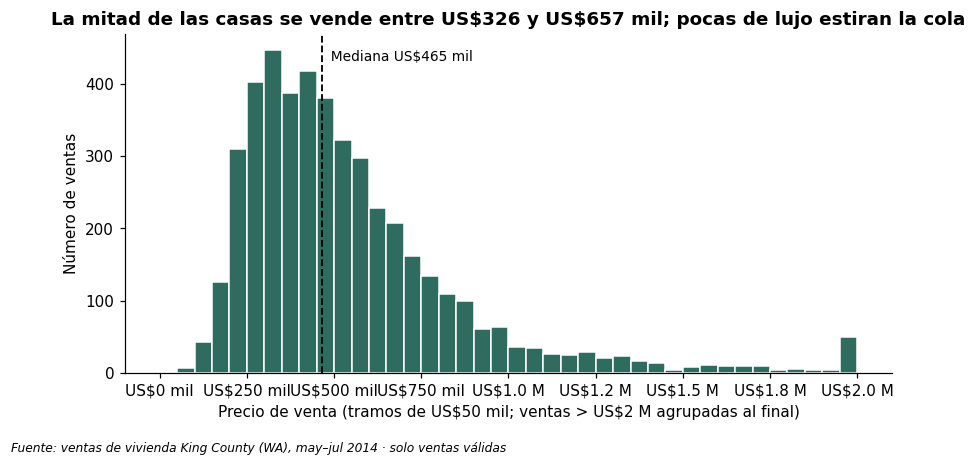

In [102]:
# Gráfico 1
med, p25, p75 = validas["precio"].median(), validas["precio"].quantile(.25), validas["precio"].quantile(.75)
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(validas["precio"].clip(upper=2e6), bins=np.arange(0, 2.05e6, 50_000), color=VERDE, edgecolor="white")
ax.axvline(med, color="black", ls="--", lw=1.2)
ax.text(med, ax.get_ylim()[1] * .92, f"  Mediana US${med/1e3:,.0f} mil", fontsize=9)
ax.xaxis.set_major_formatter(miles)
ax.set(title=f"La mitad de las casas se vende entre US${p25/1e3:,.0f} y US${p75/1e3:,.0f} mil; pocas de lujo estiran la cola",
       xlabel="Precio de venta (tramos de US$50 mil; ventas > US$2 M agrupadas al final)", ylabel="Número de ventas")
fig.text(0.01, -0.07, FUENTE, fontsize=8, style="italic"); plt.show()

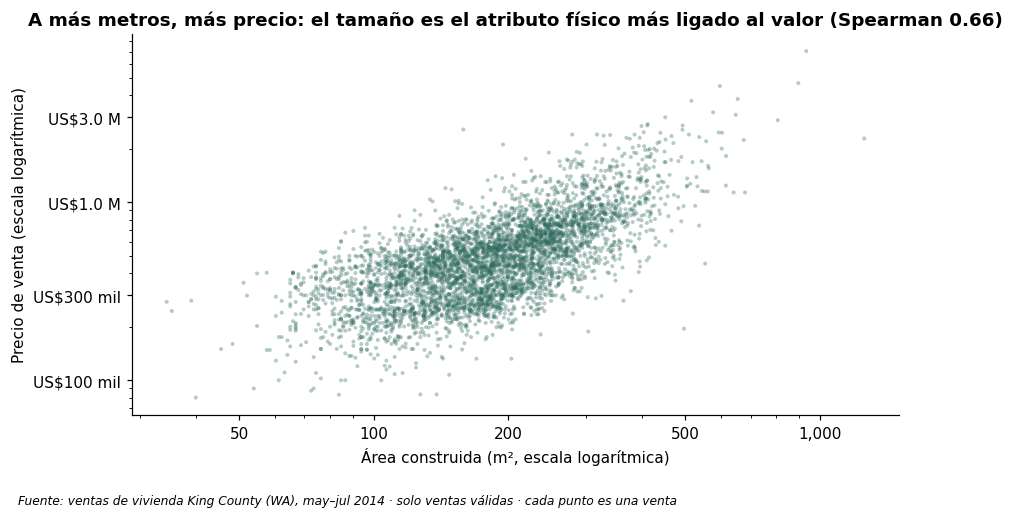

In [103]:
# Gráfico 3
m2 = validas["area_construida_sqft"].astype(float) * 0.092903
from scipy import stats
rho = stats.spearmanr(m2, validas["precio"]).statistic
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(m2, validas["precio"], s=7, alpha=0.35, color=VERDE, edgecolors="none")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xticks([50, 100, 200, 500, 1000]); ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax.set_yticks([1e5, 3e5, 1e6, 3e6]); ax.yaxis.set_major_formatter(miles)
ax.set(title=f"A más metros, más precio: el tamaño es el atributo físico más ligado al valor (Spearman {rho:.2f})",
       xlabel="Área construida (m², escala logarítmica)", ylabel="Precio de venta (escala logarítmica)")
fig.text(0.01, -0.07, FUENTE + " · cada punto es una venta", fontsize=8, style="italic"); plt.show()

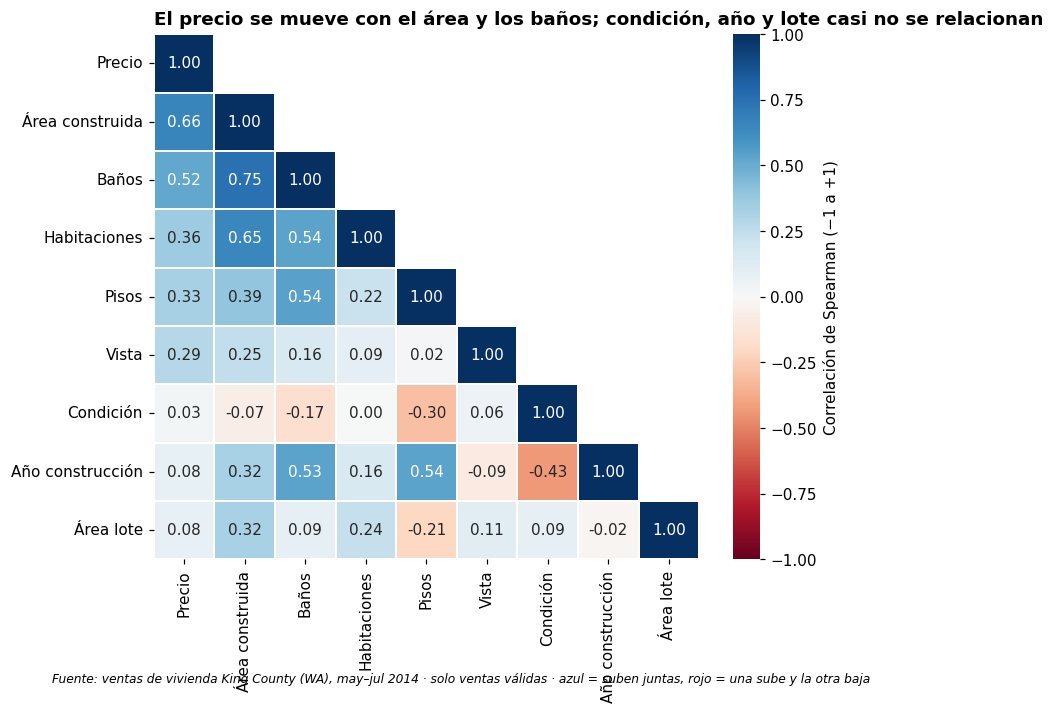

In [104]:
# Gráfico 4 (Spearman: mismo criterio que la evaluación de variables de la sección 8)
cols = {"precio": "Precio", "area_construida_sqft": "Área construida", "banos": "Baños", "habitaciones": "Habitaciones",
        "pisos": "Pisos", "vista": "Vista", "condicion": "Condición", "anio_construccion": "Año construcción", "area_lote_sqft": "Área lote"}
corr = validas[list(cols)].astype(float).corr(method="spearman").rename(index=cols, columns=cols)
fig, ax = plt.subplots(figsize=(8, 6.2))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool), k=1), annot=True, fmt=".2f", cmap="RdBu", center=0,
            vmin=-1, vmax=1, linewidths=1, cbar_kws={"label": "Correlación de Spearman (−1 a +1)"}, ax=ax)
ax.set_title("El precio se mueve con el área y los baños; condición, año y lote casi no se relacionan", loc="left")
fig.text(0.01, -0.07, FUENTE + " · azul = suben juntas, rojo = una sube y la otra baja", fontsize=8, style="italic"); plt.show()

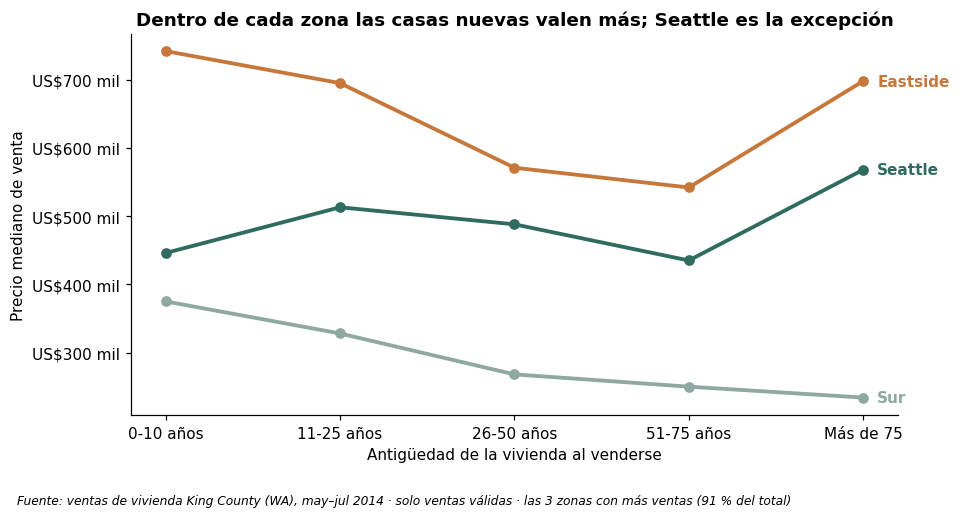

In [105]:
# Gráfico 5  — sale de la Consulta E
orden = ["Eastside", "Seattle", "Sur"]
colores = {"Eastside": COBRE, "Seattle": VERDE, "Sur": GRIS}
fig, ax = plt.subplots(figsize=(9, 4.5))
for z in orden:
    y = zona_antiguedad.loc[z].drop("pct_casas_mas_75")
    ax.plot(y.index, y.values, marker="o", lw=2.5, color=colores[z], label=z)
    ax.text(len(y) - 1 + 0.08, y.values[-1], z, color=colores[z], va="center", fontsize=10, fontweight="bold")
ax.yaxis.set_major_formatter(miles)
ax.set(title="Dentro de cada zona las casas nuevas valen más; Seattle es la excepción",
       xlabel="Antigüedad de la vivienda al venderse", ylabel="Precio mediano de venta")
fig.text(0.01, -0.07, FUENTE + " · las 3 zonas con más ventas (91 % del total)", fontsize=8, style="italic"); plt.show()

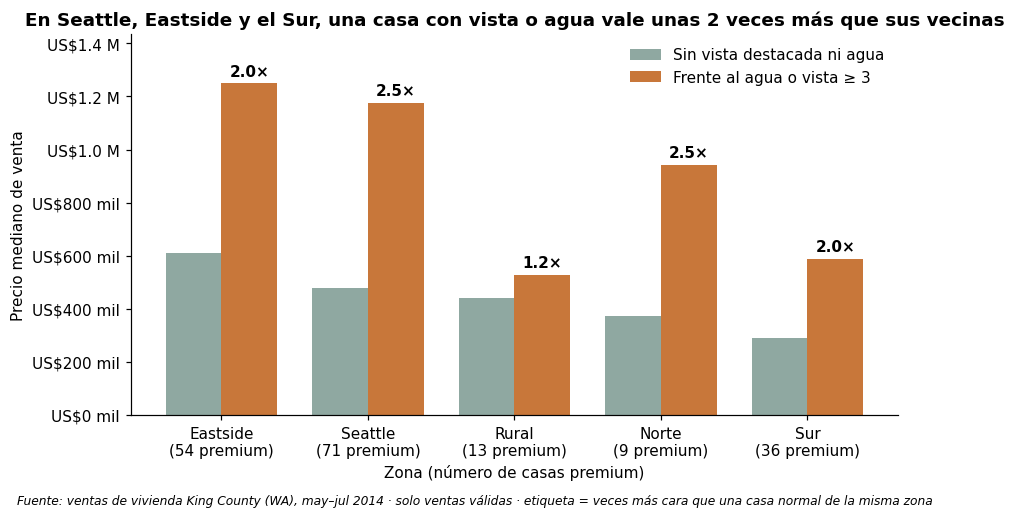

In [106]:
# Gráfico 6  — sale de la Consulta F
p = prima_premium.set_index("zona").loc[["Eastside", "Seattle", "Rural", "Norte", "Sur"]]
x = np.arange(len(p)); w = 0.38
fig, ax = plt.subplots(figsize=(9, 4.5))
b1 = ax.bar(x - w/2, p["mediana_normal"], w, color=GRIS, label="Sin vista destacada ni agua")
b2 = ax.bar(x + w/2, p["mediana_premium"], w, color=COBRE, label="Frente al agua o vista ≥ 3")
ax.bar_label(b2, labels=[f"{v:.1f}×" for v in p["veces_mas_cara"]], padding=3, fontsize=10, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels([f"{z}\n({n} premium)" for z, n in zip(p.index, p["casas_premium"])])
ax.yaxis.set_major_formatter(miles); ax.set_ylim(0, p["mediana_premium"].max() * 1.15)
ax.set(title="En Seattle, Eastside y el Sur, una casa con vista o agua vale unas 2 veces más que sus vecinas",
       xlabel="Zona (número de casas premium)", ylabel="Precio mediano de venta")
ax.legend(frameon=False, loc="upper right")
fig.text(0.01, -0.07, FUENTE + " · etiqueta = veces más cara que una casa normal de la misma zona", fontsize=8, style="italic"); plt.show()

## 7. Preguntas y respuestas sobre los gráficos

**Gráfico 1 — ¿La mayoría de las casas se vende a un precio parecido?**
No exactamente. La mitad de las ventas está entre US$326 y US$657 mil, pero un grupo pequeño de casas de lujo (hasta US$7 M) estira la cola derecha. Por eso el precio “típico” se describe con la **mediana (US$465 mil)** y no con el promedio (US$549 mil).

**Gráfico 2 — ¿Todas las ciudades tienen precios parecidos?**
No. Mercer Island (US$950 mil), Bellevue y Sammamish están muy por encima; Seattle queda en US$490 mil y las ciudades del sur (fuera de este top 10) rondan US$250–345 mil. La ciudad es uno de los factores que más cambia el valor de una vivienda.

**Gráfico 3 — ¿Las casas más grandes valen más?**
Sí: a mayor área, mayor precio (Spearman 0,66). Pero la nube es ancha: a igual tamaño hay casas mucho más caras que otras, lo que confirma que la ubicación y otros atributos también influyen.

**Gráfico 4 — ¿Qué variables se mueven junto con el precio?**
El área construida y los baños son las que más lo acompañan. El año de construcción, la condición y el tamaño del lote casi no muestran relación directa… **hasta que se controla la zona** (Gráfico 5).

**Gráfico 5 — ¿La antigüedad importa? (nuevo)**
Sí, pero solo se ve al comparar dentro de cada zona: en Eastside y el Sur las casas de 0–10 años cuestan entre 37 % y 50 % más que las de 51–75 años. Seattle es la excepción (sus casas centenarias son las más caras). **Acción:** nunca juzgar la antigüedad sin mirar la ubicación.

**Gráfico 6 — ¿Cuánto vale la vista o el agua? (nuevo)**
En Seattle, Eastside y el Sur una casa premium vale entre 2,0 y 2,5 veces más que una normal de su misma zona (en Norte y Rural hay muy pocas para concluir). Son pocas casas (183 en total), pero es el efecto individual más grande del análisis. **Acción:** tratarla como un ajuste explícito al fijar precios.

### 7.1 ¿Por qué estos 6 gráficos y estas 7 consultas, y no otros?

**Criterio de selección.** Cada gráfico o consulta se conservó solo si cumplía tres condiciones: (1) responde una pregunta de negocio distinta, (2) su hallazgo cambia una decisión (fijar precio, elegir zona, verificar un dato) y (3) no repite lo que ya muestra otro.

| Se incluyó | Por qué |
|---|---|
| Gráf. 1 · Distribución del precio | Define el Target y justifica usar mediana y logaritmo |
| Gráf. 2 · Precio por ciudad | Muestra el factor de ubicación en su forma más fácil de entender |
| Gráf. 3 · Precio vs. área | El atributo físico más fuerte |
| Gráf. 4 · Correlaciones | Resume en una sola imagen cómo se relacionan 9 variables y cuáles son redundantes |
| Gráf. 5 · Antigüedad × zona (nuevo) | Corrige una conclusión falsa (“la antigüedad no importa”) |
| Gráf. 6 · Prima de vista/agua (nuevo) | El efecto más grande, que la correlación subestima por ser pocas casas |
| Consultas A–C | Ranking de ciudades, antigüedad y comparación con el código postal |
| Consultas D–G (nuevas) | Cubren LEFT/INNER JOIN y funciones de ventana, y sirven para control de calidad y análisis por zona |

| Se dejó fuera | Por qué |
|---|---|
| Distribución por zona y por antigüedad (barras de conteo) | Describen volumen, no precio; se resumen en una frase |
| Mapa de calor zona × antigüedad | El Gráfico 5 muestra lo mismo con precios, que es lo que importa |
| Cajas de precio por condición | Resultado confuso sin controlar edad (las casas “Promedio” son más nuevas) |
| Precio por mes o día de la semana | Sin relación con el precio en una ventana de 70 días |
| Ranking de las 36 variables en gráfico | Ya está en la tabla de la sección 8 |
| Consultas de exploración fila a fila (`SELECT *`) | Útiles para revisar, pero no aportan conclusiones |

## 8. Evaluacion de variables frente al precio (el Target)

Antes de comparar variables necesitamos decir claramente que estamos tratando de explicar: el **Target** o variable objetivo. En este caso es el **precio de venta** (`precio`). Tambien usamos dos versiones auxiliares: `log_precio` (el mismo precio en escala logaritmica, para que las comparaciones no se distorsionen por las casas de lujo) y `precio_alto` (una marca de si/no para el 25% de ventas mas caras, util para hablar en porcentajes). Con esto evaluamos que tan relacionada esta cada variable con el precio.

In [107]:
from scipy import stats

validas["log_precio"] = np.log(validas["precio"])
validas["precio_alto"] = (validas["precio"] >= validas["precio"].quantile(0.75)).astype(int)

# Se reutiliza el mismo catálogo de zonas (dim_zonas) usado en SQL, que cubre las 44 ciudades
ciudad_a_zona = dict(zip(dim_zonas.ciudad, dim_zonas.zona))
validas["zona"] = validas["ciudad"].astype(str).map(ciudad_a_zona).fillna("Otra")
validas["ubicacion_premium"] = validas["frente_agua"].astype(bool) | (validas["vista"] >= 3)
validas["area_construida_m2"] = validas["area_construida_sqft"].astype(float) * 0.092903
validas["banos_por_habitacion"] = (validas["banos"] / validas["habitaciones"].astype(float).replace(0, np.nan)).round(2)
validas["m2_por_habitacion"] = (validas["area_construida_m2"] / validas["habitaciones"].astype(float).replace(0, np.nan)).round(1)

candidatas_numericas = ["area_construida_m2", "m2_por_habitacion", "banos", "habitaciones", "pisos",
                        "banos_por_habitacion", "condicion", "anio_construccion", "area_lote_sqft", "vista"]
resultado = []
for v in candidatas_numericas:
    rho = stats.spearmanr(validas[v].astype(float), validas["log_precio"], nan_policy="omit").statistic
    resultado.append([v, round(abs(rho), 2)])

def relacion_por_grupo(y, g):
    d = pd.DataFrame({"y": y, "g": g.astype(str)}).dropna()
    media = d["y"].mean()
    entre = d.groupby("g")["y"].apply(lambda s: len(s) * (s.mean() - media) ** 2).sum()
    return entre / ((d["y"] - media) ** 2).sum()

resultado.append(["zona", round(relacion_por_grupo(validas["log_precio"], validas["zona"]), 2)])
resultado.append(["ubicacion_premium", round(relacion_por_grupo(validas["log_precio"], validas["ubicacion_premium"]), 2)])

tabla_evaluacion

,Variable,Fuerza de relacion con el precio
0,area_construida_m2,0.66
1,m2_por_habitacion,0.56
2,banos,0.52
3,habitaciones,0.36
4,pisos,0.33
5,banos_por_habitacion,0.31
10,zona,0.30
9,vista,0.29
8,area_lote_sqft,0.08
7,anio_construccion,0.08


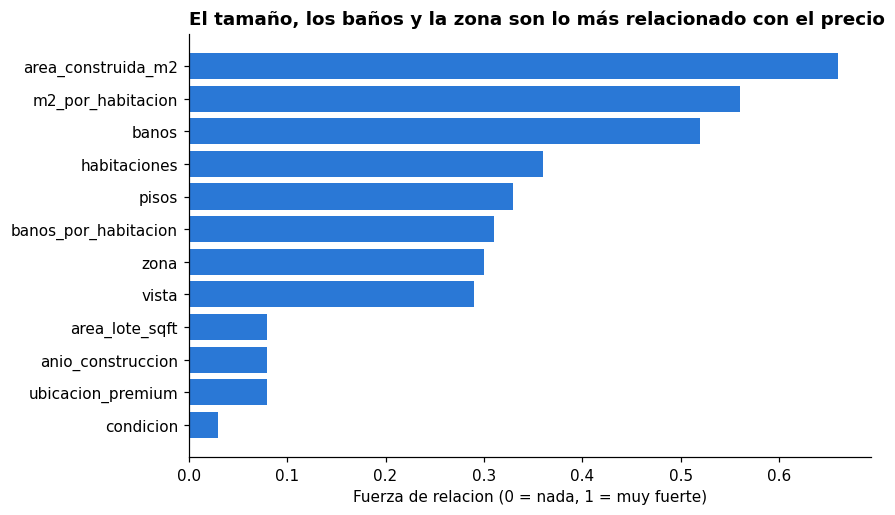

In [108]:
plt.figure(figsize=(8, 5))
plt.barh(tabla_evaluacion["Variable"][::-1], tabla_evaluacion["Fuerza de relacion con el precio"][::-1], color="#2a78d6")
plt.title("El tamaño, los baños y la zona son lo más relacionado con el precio", loc="left")
plt.xlabel("Fuerza de relacion (0 = nada, 1 = muy fuerte)")
plt.show()

**Que significa este ranking.** Las variables con mayor relacion con el precio son el tamano (`area_construida_m2`), la zona, los banos, las habitaciones, los pisos y la proporcion de banos por habitacion; tambien incluimos `ubicacion_premium` porque, aunque su numero de relacion es bajo (0,08), afecta a pocas casas con un efecto muy grande: su precio mediano es 2,2 veces el del resto y la prima se mantiene dentro de cada zona con suficientes casas (Consulta F y Grafico 6). Con esas ocho variables cubrimos los tres aspectos principales que definen el precio: el tamano, la distribucion interna de la casa y la ubicacion. Son las que se conservan para un futuro modelo.

## 9. Analisis final del ejercicio

**Resumen del proceso.** Partimos de un archivo que parecia limpio (sin celdas vacias ni filas duplicadas) pero que en realidad escondia varios problemas: 49 ventas con precio en cero, 5 precios por pie cuadrado absurdos, 2 viviendas con 0 habitaciones y 0 banos, y cientos de anos de renovacion mal registrados. Ninguno de esos registros se elimino; todos se marcaron con banderas, de modo que el 98,8% de las ventas (4.546 de 4.600) quedaron disponibles para analizar el precio, y el resto sigue existiendo en la base para no perder informacion sobre esas viviendas. Despues de limpiar, se le dio a cada columna el tipo de dato correcto (fechas, textos, numeros enteros y decimales), lo que dejo una base solida de 22 variables confiables. Con esa base se hicieron consultas en SQL para responder preguntas de negocio (que ciudades son mas caras, como cambia el precio segun la antiguedad, y que tanto se paga por encima del precio tipico de cada codigo postal), y se construyeron graficos que mostraron el mismo patron una y otra vez: el precio depende sobre todo del tamano de la casa y de donde esta ubicada. Las consultas con JOIN y funciones de ventana agregaron tres hallazgos: las viviendas sin precio estan repartidas en todas las zonas (no sesgan), dentro de cada zona las casas nuevas si valen mas, y la vista o el agua multiplican el precio por unas 2 veces (2,0 a 2,5) frente a las vecinas de la misma zona.

**Por que se escogieron solo 8 variables.** Evaluamos muchas variables candidatas (mas de 25 en el analisis completo) midiendo que tanto se relaciona cada una con el precio. Al final se conservaron 8: el area construida en metros cuadrados, los metros cuadrados por habitacion, el numero de banos, el numero de habitaciones, el numero de pisos, la proporcion de banos por habitacion, la zona geografica y si la vivienda tiene una ubicacion premium (frente al agua o muy buena vista). Estas ocho cubren, sin repetirse, los tres grandes factores que mueven el precio: cuanto espacio tiene la casa, como esta distribuido ese espacio, y en que zona esta. Se escogieron por tener una relacion clara y consistente con el precio, y porque entre ellas no se repite informacion: por ejemplo, no se incluyeron a la vez el area construida y el area "sobre el nivel del suelo", porque miden casi lo mismo (se mueven juntas en un 84% de los casos) y usar las dos solo anadiria ruido sin aportar nada nuevo.

**Por que las demas no se escogieron.** Las variables descartadas caen en cuatro grupos. Primero, las que se calculan directamente a partir del precio (el precio promedio de la ciudad, el precio relativo al codigo postal, la banda de precio, o la marca de "precio alto" usada como variable explicativa): usarlas para explicar el precio seria hacer trampa, porque ya contienen la respuesta. Segundo, las redundantes: variables que repiten casi la misma informacion que otra ya conservada, como el area sobre el nivel del suelo (casi identica al area construida) o el porcentaje de sotano (que es exactamente el complemento de otra variable ya evaluada); incluir ambas no mejora el analisis, solo lo complica. Tercero, las que no mostraron ninguna relacion con el precio en este periodo de datos, como el mes de venta, el dia de la semana o el tamano del lote; esto no significa que nunca importen, sino que en esta ventana de solo 70 dias no se alcanza a ver su efecto. Cuarto, hay un grupo intermedio para "revisar mas adelante": la antiguedad de la vivienda, su condicion y la calidad de la vista. Por si solas parecen tener poca relacion con el precio, pero el analisis por zona mostro que si importan cuando se consideran junto con la ubicacion (por ejemplo, dentro de cada zona las casas mas nuevas si tienden a costar mas). Se dejaron fuera de las 8 variables "seguras" no porque no sirvan, sino porque su efecto solo se ve combinandolas con otras, y eso requiere un modelo mas completo que un simple ranking de variables individuales.

**Limitaciones y que sigue.** Este analisis cubre solo 70 dias de un unico mercado (King County, 2014), por lo que no permite ver tendencias de varios anos ni trasladarse a otras ciudades. Ademas, todo lo encontrado son relaciones (asociaciones), no pruebas de que una caracteristica "cause" el precio. El siguiente paso natural es construir un modelo de prediccion usando estas 8 variables como punto de partida, revisando tambien si la antiguedad, la condicion o la vista aportan algo adicional una vez que la zona y el tamano ya estan incluidos.